##  Configuration & Imports

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── SET THIS to your results folder ──────────────────────────────────────────
RESULTS_DIR = os.path.join(os.getcwd(), 'results_all_experiments')
# ─────────────────────────────────────────────────────────────────────────────

METRICS_DIR = os.path.join(RESULTS_DIR, 'metrics')
STATS_DIR   = os.path.join(RESULTS_DIR, 'statistics')
ALL_METRICS           = ['MAE', 'MSE', 'RMSE', 'MAPE', 'SMAPE', 'R2']
METRICS_LOWER_BETTER  = {'MAE', 'MSE', 'RMSE', 'MAPE', 'SMAPE'}
METRICS_HIGHER_BETTER = {'R2'}

MODEL_COLORS = {
    'VMD_Optuna_TCN': '#2196F3',
    'GRU':            '#FF9800',
    'LSTM':           '#4CAF50',
    'Transformer':    '#9C27B0',
}
_DEFAULT_COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

def model_color(name, idx=0):
    return MODEL_COLORS.get(name, _DEFAULT_COLORS[idx % len(_DEFAULT_COLORS)])

def sig_star(p):
    try: p = float(p)
    except: return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def load_csv(path):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'Loaded: {path}  ({len(df)} rows)')
        return df
    print(f'NOT FOUND: {path}')
    return pd.DataFrame()

print('Configuration ready. RESULTS_DIR =', RESULTS_DIR)

Configuration ready. RESULTS_DIR = c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments


##  Load All CSVs

In [2]:
metrics_df = load_csv(os.path.join(METRICS_DIR, 'all_metrics.csv'))
history_df = load_csv(os.path.join(METRICS_DIR, 'training_history.csv'))
error_df   = load_csv(os.path.join(STATS_DIR,   'absolute_error_long.csv'))
dm_df      = load_csv(os.path.join(STATS_DIR,   'dm_tests.csv'))
wilcox_df  = load_csv(os.path.join(STATS_DIR,   'wilcoxon_error_tests.csv'))
bw_df      = load_csv(os.path.join(STATS_DIR,   'block_level_wilcoxon_tests.csv'))
fr_df      = load_csv(os.path.join(STATS_DIR,   'friedman_tests.csv'))

Loaded: c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\metrics\all_metrics.csv  (52 rows)
Loaded: c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\metrics\training_history.csv  (100 rows)
Loaded: c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\statistics\absolute_error_long.csv  (109920 rows)
Loaded: c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\statistics\dm_tests.csv  (78 rows)
Loaded: c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\statistics\wilcoxon_error_tests.csv  (39 rows)
Loaded: c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\statistics\block_level_wilcoxon_tests.csv  (12 rows)
Loaded: c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\stat

##  Absolute Error Distributions

### Box Plot

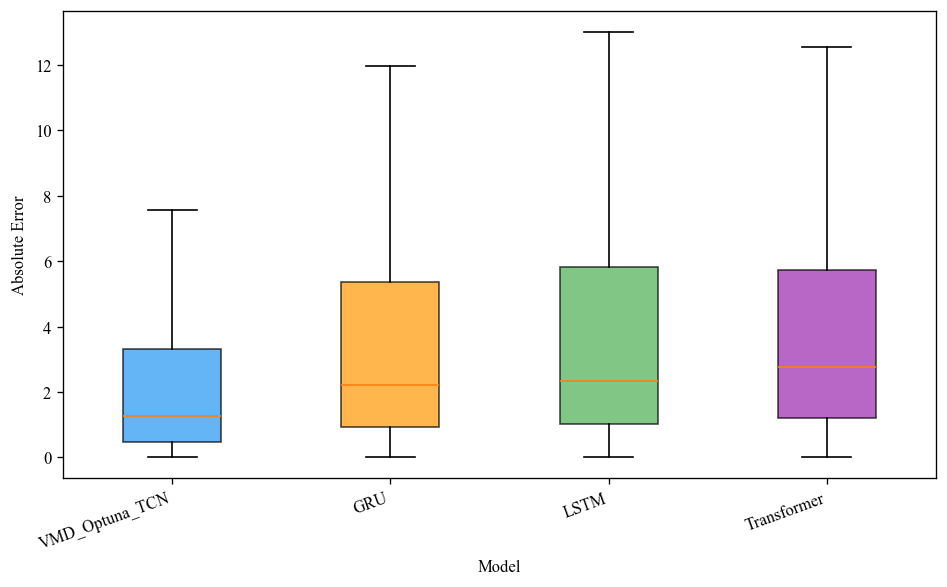

In [3]:
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})
if not error_df.empty:
    models_in = error_df['Model'].unique().tolist()
    data   = [error_df.loc[error_df['Model']==m, 'Abs_Error'].dropna().values for m in models_in]
    colors = [model_color(m, i) for i, m in enumerate(models_in)]

    fig, ax = plt.subplots(figsize=(max(7, len(models_in)*2), 5))
    bp = ax.boxplot(data, labels=models_in, showfliers=False, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_ylabel('Absolute Error'); ax.set_xlabel('Model')
    # ax.set_title('Absolute Error Distribution — Box Plot (no outliers)')
    ax.set_xticklabels(models_in, rotation=20, ha='right')
    fig.tight_layout()
    plt.show()
    plt.close()

### Violin Plot

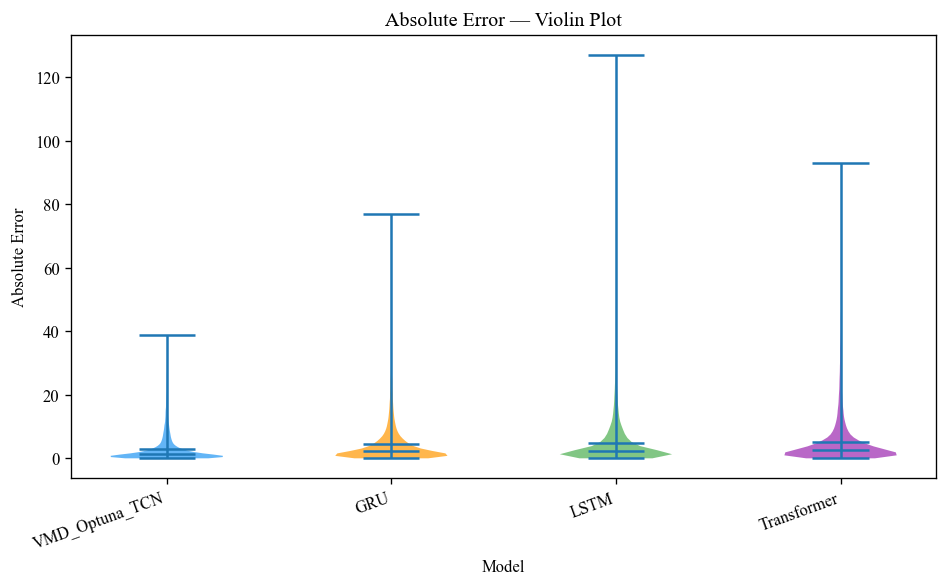

In [4]:
if not error_df.empty:
    models_in = error_df['Model'].unique().tolist()
    data   = [error_df.loc[error_df['Model']==m, 'Abs_Error'].dropna().values for m in models_in]
    colors = [model_color(m, i) for i, m in enumerate(models_in)]

    fig, ax = plt.subplots(figsize=(max(7, len(models_in)*2), 5))
    parts = ax.violinplot(data, showmeans=True, showmedians=True)
    for body, c in zip(parts['bodies'], colors):
        body.set_facecolor(c); body.set_alpha(0.7)
    ax.set_xticks(range(1, len(models_in)+1))
    ax.set_xticklabels(models_in, rotation=20, ha='right')
    ax.set_ylabel('Absolute Error'); ax.set_xlabel('Model')
    ax.set_title('Absolute Error — Violin Plot')
    fig.tight_layout()
    plt.show()
    plt.close()

##  Diebold–Mariano Tests

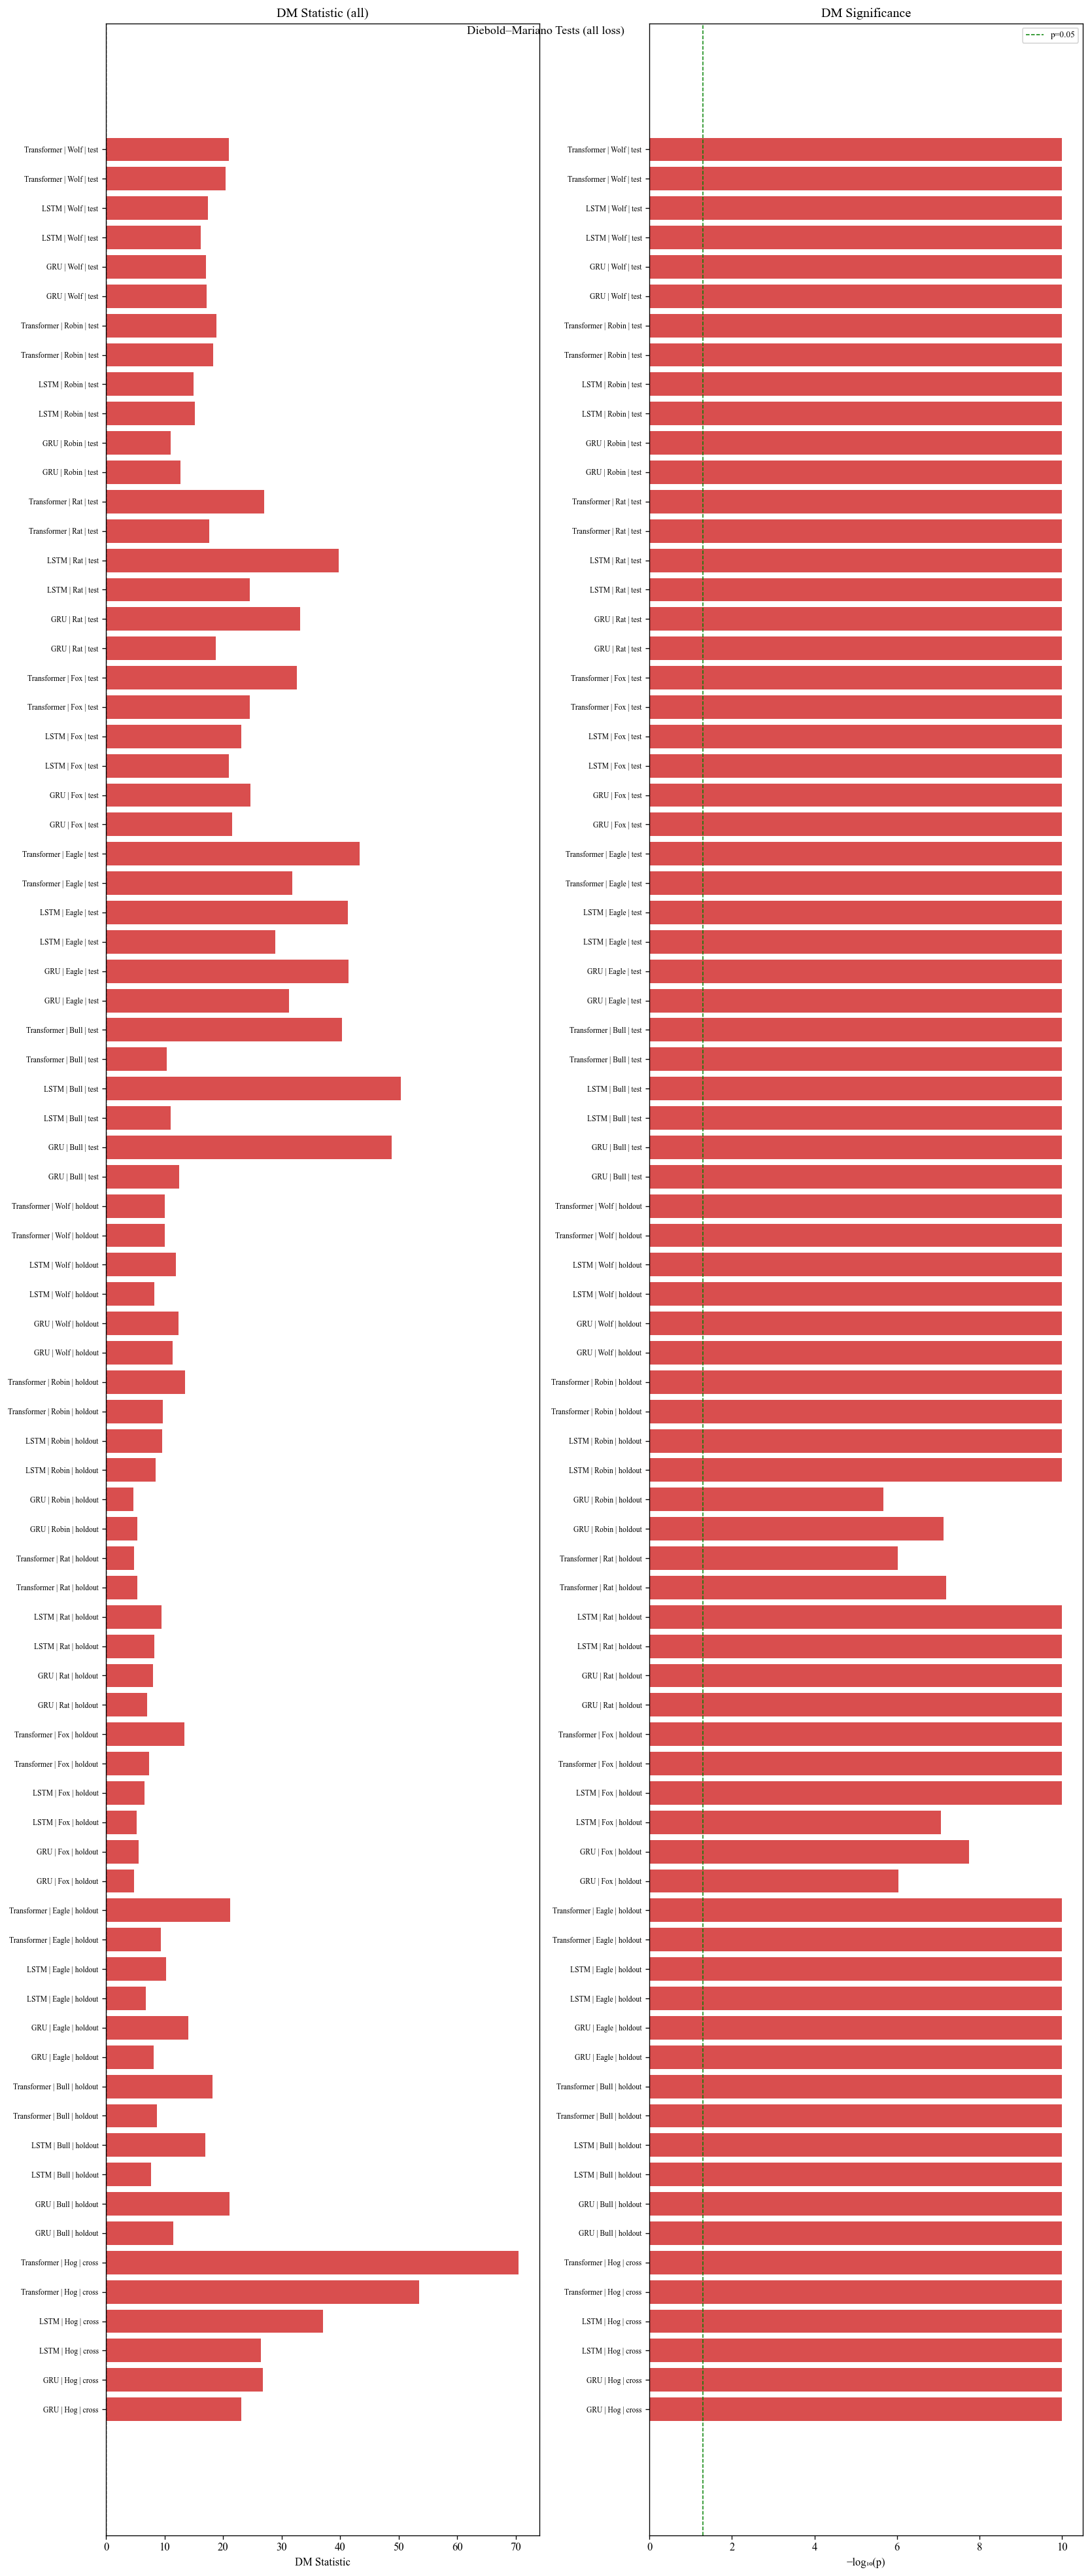

In [5]:
if not dm_df.empty and 'P_Value' in dm_df.columns:
    dm_df = dm_df.copy()
    dm_df['neg_log_p'] = -np.log10(dm_df['P_Value'].clip(lower=1e-10))

    groups = dm_df.groupby('Loss_Type') if 'Loss_Type' in dm_df.columns else [('all', dm_df)]
    for loss_type, sub in groups:
        sub = sub.copy()
        sig_col = sub['P_Value'].apply(lambda p: (
            '#d32f2f' if p<0.001 else '#f57c00' if p<0.01 else '#388e3c' if p<0.05 else '#9e9e9e'))

        def row_label(row):
            return ' | '.join(str(row[c]) for c in ['Baseline_Model','Building','Dataset']
                              if c in row.index and pd.notna(row[c]))
        labels = [row_label(r) for _, r in sub.iterrows()]

        fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(sub)*0.4+2)))

        axes[0].barh(range(len(sub)), sub['DM_Statistic'].values, color=sig_col, alpha=0.85)
        axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
        axes[0].set_yticks(range(len(sub))); axes[0].set_yticklabels(labels, fontsize=7)
        axes[0].set_xlabel('DM Statistic'); axes[0].set_title(f'DM Statistic ({loss_type})')

        axes[1].barh(range(len(sub)), sub['neg_log_p'].values, color=sig_col, alpha=0.85)
        axes[1].axvline(-np.log10(0.05), color='green', linestyle='--', linewidth=0.9, label='p=0.05')
        axes[1].set_yticks(range(len(sub))); axes[1].set_yticklabels(labels, fontsize=7)
        axes[1].set_xlabel('−log₁₀(p)'); axes[1].set_title('DM Significance')
        axes[1].legend(fontsize=8)

        fig.suptitle(f'Diebold–Mariano Tests ({loss_type} loss)', fontsize=11)
        fig.tight_layout()
        plt.show()
        plt.close()

In [6]:
if not dm_df.empty and 'P_Value' in dm_df.columns:
    dm_df = dm_df.copy()
    if 'Dataset' in dm_df.columns:
        dm_df = dm_df[dm_df['Dataset'].str.lower() == 'test']
    dm_df['neg_log_p'] = -np.log10(dm_df['P_Value'].clip(lower=1e-10))
    groups = dm_df.groupby('Loss_Type') if 'Loss_Type' in dm_df.columns else [('all', dm_df)]

    for loss_type, sub in groups:
        sub = sub.copy()

        def row_label(row):
            return ' | '.join(str(row[c]) for c in ['Baseline_Model', 'Building', 'Dataset']
                              if c in row.index and pd.notna(row[c]))

        table_df = pd.DataFrame({
            'Model':          [row_label(r) for _, r in sub.iterrows()],
            'DM Statistic':   sub['DM_Statistic'].round(4).values,
            'P-Value':        sub['P_Value'].apply(lambda p: f'{p:.16f}').values,
            '−log₁₀(p)':     sub['neg_log_p'].round(3).values,
        })

        print(f"Proposed model (VMD-Optuna-TCN) compare on GRU, LSTM, Transformer \nDiebold–Mariano Tests")
        print("=" * 80)
        try:
            from tabulate import tabulate
            print(tabulate(table_df, headers='keys', tablefmt='simple', showindex=False))
        except ImportError:
            print(table_df.to_string(index=False))
        print("=" * 80)

Proposed model (VMD-Optuna-TCN) compare on GRU, LSTM, Transformer 
Diebold–Mariano Tests
Model                         DM Statistic    P-Value    −log₁₀(p)
--------------------------  --------------  ---------  -----------
GRU | Bull | test                  12.5317          0           10
GRU | Bull | test                  48.849           0           10
LSTM | Bull | test                 10.9981          0           10
LSTM | Bull | test                 50.3521          0           10
Transformer | Bull | test          10.3188          0           10
Transformer | Bull | test          40.3099          0           10
GRU | Eagle | test                 31.3085          0           10
GRU | Eagle | test                 41.4416          0           10
LSTM | Eagle | test                28.8676          0           10
LSTM | Eagle | test                41.3317          0           10
Transformer | Eagle | test         31.7987          0           10
Transformer | Eagle | test         43.28

In [7]:
# ── Block-Level Wilcoxon Tests Table ─────────────────────────────────────────
if not bw_df.empty:
    b = bw_df.copy()
    b['Sig'] = b['P_Value'].apply(sig_star)

    col_map = {
        'Metric':                            'Metric',
        'Baseline_Model':                    'Baseline',
        'Statistic':                         'W Statistic',
        'P_Value':                           'p-value',
        'Median_Diff_BaselineMinusProposed': 'Median Diff (Base-Prop)'
    }
    display_cols = [c for c in col_map if c in b.columns]
    table = b[display_cols].rename(columns=col_map)
    table['p-value'] = table['p-value'].map(lambda x: f'{x:.4f}' if pd.notna(x) else '-')
    if 'Median Diff (Base-Prop)' in table.columns:
        table['Median Diff (Base-Prop)'] = table['Median Diff (Base-Prop)'].map(
            lambda x: f'{x:.4f}' if pd.notna(x) else '-')

    print('=== Block-Level Wilcoxon Tests ===')
    print('(*** p<0.001  ** p<0.01  * p<0.05  ns)\n')
    display(table.reset_index(drop=True))

=== Block-Level Wilcoxon Tests ===
(*** p<0.001  ** p<0.01  * p<0.05  ns)



,Metric,Baseline,W Statistic,p-value,Median Diff (Base-Prop)
0,MAE,GRU,91.0,0.0001,1.4004
1,MAE,LSTM,91.0,0.0001,2.2518
2,MAE,Transformer,91.0,0.0001,2.3554
3,RMSE,GRU,91.0,0.0001,2.8836
4,RMSE,LSTM,91.0,0.0001,2.9174
5,RMSE,Transformer,91.0,0.0001,3.2232
6,MAPE,GRU,91.0,0.0001,2.5900
7,MAPE,LSTM,91.0,0.0001,3.0486
8,MAPE,Transformer,91.0,0.0001,3.2266
9,SMAPE,GRU,91.0,0.0001,2.5283


In [8]:
# ── Combined Pivot Summary Table ──────────────────────────────────────────────
if not bw_df.empty:
    b = bw_df.copy()
    b['Cell'] = b.apply(
        lambda r: f"{r['P_Value']:.4f} {sig_star(r['P_Value'])}"
                  if pd.notna(r.get('P_Value')) else '-', axis=1)

    pivot = b.pivot_table(index='Metric', columns='Baseline_Model',
                          values='Cell', aggfunc='first')
    pivot = pivot.reindex(index=[m for m in ['MAE','MSE','RMSE','MAPE','SMAPE','R2']
                                  if m in pivot.index])
    pivot.columns.name = None
    pivot.index.name = 'Metric'

    print('=== Block Wilcoxon — Pivot Summary (p-value + significance) ===')
    print('(*** p<0.001  ** p<0.01  * p<0.05  ns)\n')
    display(pivot)

=== Block Wilcoxon — Pivot Summary (p-value + significance) ===
(*** p<0.001  ** p<0.01  * p<0.05  ns)



,GRU,LSTM,Transformer
Metric,,,
MAE,0.0001 ***,0.0001 ***,0.0001 ***
RMSE,0.0001 ***,0.0001 ***,0.0001 ***
MAPE,0.0001 ***,0.0001 ***,0.0001 ***
SMAPE,0.0001 ***,0.0001 ***,0.0001 ***
